In [1]:
# RC-1 — Config and data loading
#
# Standalone section. Depends on no prior cells in this notebook.
# All paths and constants must match 02_embeddings.ipynb and 03_exploration.ipynb.

from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

DATA_ROOT      = Path.home() / "vambersky_t/Data"
WINDOWS_DIR    = DATA_ROOT / "extracted_windows_hg38"
EMBEDDINGS_DIR = DATA_ROOT / "embeddings_hg38"
CACHE_DIR      = DATA_ROOT / "exploration_hg38" / "cache_hg38"
FIGURES_DIR    = DATA_ROOT / "exploration_hg38" / "figures_hg38"

SEQ_LEN   = 10_000
BIN_SIZE  = 50
N_BINS    = SEQ_LEN // BIN_SIZE   # 200
EMBED_DIM = 4096
WARMUP_BINS = 15                  # bins 0..14 excluded from trimmed analyses
RANDOM_SEED = 42

FWD_BASE    = "ENCFF765CKK__MYC__GM12878"
TF          = "MYC"
RC_BASE     = "ENCFF765CKK__MYC__GM12878_revcomp"

# Paths — forward (existing cache)
fwd_cache_npz     = CACHE_DIR / TF / f"{FWD_BASE}.derived.npz"
fwd_cache_parquet = CACHE_DIR / TF / f"{FWD_BASE}.peak_meta.parquet"
fwd_windows_path  = WINDOWS_DIR / TF / f"{FWD_BASE}.full_peaks.csv.gz"

# Paths — RC (raw embeddings; no separate cache needed)
rc_npz_path     = EMBEDDINGS_DIR / f"{TF}_revcomp" / f"{RC_BASE}.embeddings.npz"
rc_parquet_path = EMBEDDINGS_DIR / f"{TF}_revcomp" / f"{RC_BASE}.peak_ids.parquet"

for p in (fwd_cache_npz, fwd_cache_parquet, fwd_windows_path, rc_npz_path, rc_parquet_path):
    assert p.exists(), f"Missing: {p}"

# x-axis: bp relative to peak centre, at bin centres
bin_coords = (np.arange(N_BINS) * BIN_SIZE) + (BIN_SIZE // 2) - (SEQ_LEN // 2)
assert bin_coords[0] == -4975 and bin_coords[-1] == 4975
trim_mask = np.arange(N_BINS) >= WARMUP_BINS   # (N_BINS,) bool; True = kept in trimmed analyses

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.dpi"]  = 120
plt.rcParams["svg.fonttype"] = "none"

print(f"Forward cache:  {fwd_cache_npz}")
print(f"RC embeddings:  {rc_npz_path}")
print(f"Trim mask:      bins {WARMUP_BINS}..{N_BINS-1} ({trim_mask.sum()} bins)")

Forward cache:  /home/jovyan/vambersky_t/Data/exploration_hg38/cache_hg38/MYC/ENCFF765CKK__MYC__GM12878.derived.npz
RC embeddings:  /home/jovyan/vambersky_t/Data/embeddings_hg38/MYC_revcomp/ENCFF765CKK__MYC__GM12878_revcomp.embeddings.npz
Trim mask:      bins 15..199 (185 bins)


In [2]:
# RC-2 — Load forward cache and RC embeddings
#
# The forward keep_mask (peaks dropped due to all-N bins) is authoritative:
# the RC embeddings were produced from the same peak set in the same order,
# so the same row indices are invalid.

# --- forward derived quantities (from cache) ---
fwd_cached = np.load(fwd_cache_npz)
fwd_keep_mask       = fwd_cached["keep_mask"]           # (n_raw_peaks,) bool
fwd_pos_profile     = fwd_cached["pos_profile"]         # (N_BINS, EMBED_DIM) float32
fwd_gc_mean_profile = fwd_cached["gc_mean_profile"]     # (N_BINS,) float32
fwd_cached.close()

n_raw  = fwd_keep_mask.shape[0]
n_kept = int(fwd_keep_mask.sum())
n_dropped = n_raw - n_kept
print(f"Forward: {n_raw} raw peaks, {n_dropped} dropped, {n_kept} kept")

# --- RC raw embeddings ---
# Load, apply same keep_mask, compute positional profile (mean over kept peaks)
rc_npz = np.load(rc_npz_path)
rc_emb = np.asarray(rc_npz["embeddings"])   # (n_raw, N_BINS, EMBED_DIM) float16
rc_npz.close()

assert rc_emb.shape == (n_raw, N_BINS, EMBED_DIM), (
    f"RC shape {rc_emb.shape} does not match expected ({n_raw}, {N_BINS}, {EMBED_DIM})"
)

rc_emb_kept = rc_emb[fwd_keep_mask]         # (n_kept, N_BINS, EMBED_DIM) float16
del rc_emb                                   # free ~2.8 GB

# positional profile: mean over peaks -> (N_BINS, EMBED_DIM) float32
rc_pos_profile = np.zeros((N_BINS, EMBED_DIM), dtype=np.float32)
chunk = 256
for s in range(0, n_kept, chunk):
    e = min(s + chunk, n_kept)
    rc_pos_profile += rc_emb_kept[s:e].astype(np.float32).sum(axis=0)
rc_pos_profile /= n_kept

print(f"RC positional profile: {rc_pos_profile.shape} {rc_pos_profile.dtype}")

# --- per-peak L2-normalised positional profile (matching Block 2b per-peak) ---
rc_pos_profile_pp = np.zeros((N_BINS, EMBED_DIM), dtype=np.float32)
for s in range(0, n_kept, chunk):
    e = min(s + chunk, n_kept)
    block = rc_emb_kept[s:e].astype(np.float32)          # (chunk, N_BINS, EMBED_DIM)
    norms = np.linalg.norm(block, axis=2, keepdims=True)  # (chunk, N_BINS, 1)
    rc_pos_profile_pp += (block / (norms + 1e-8)).sum(axis=0)
rc_pos_profile_pp /= n_kept

# Flip RC profiles from model coordinates to genomic coordinates.
# Model position 0 of the RC pass corresponds to genomic bin 199
# (the right end of the window); reversing aligns with the forward array.
rc_pos_profile    = rc_pos_profile[::-1, :]      # (N_BINS, EMBED_DIM)
rc_pos_profile_pp = rc_pos_profile_pp[::-1, :]   # (N_BINS, EMBED_DIM)

print(f"RC per-peak-normalised profile: {rc_pos_profile_pp.shape}")

# --- load forward sequences for RC computation ---
windows = pl.read_csv(fwd_windows_path).select(["peak_id", "sequence"])
fwd_meta = pl.read_parquet(fwd_cache_parquet)   # already filtered to kept peaks
# sequences in raw (pre-filter) order; filter to kept peaks using the same mask
all_seqs = windows["sequence"].to_list()
kept_seqs_fwd = [all_seqs[i] for i, keep in enumerate(fwd_keep_mask) if keep]
assert len(kept_seqs_fwd) == n_kept

RC_TABLE = str.maketrans("ACGTNacgtn", "TGCANtgcan")
kept_seqs_rc = [s.translate(RC_TABLE)[::-1] for s in kept_seqs_fwd]

print(f"Sequences loaded: {len(kept_seqs_fwd)} forward, {len(kept_seqs_rc)} RC")

Forward: 2239 raw peaks, 1 dropped, 2238 kept
RC positional profile: (200, 4096) float32
RC per-peak-normalised profile: (200, 4096)
Sequences loaded: 2238 forward, 2238 RC


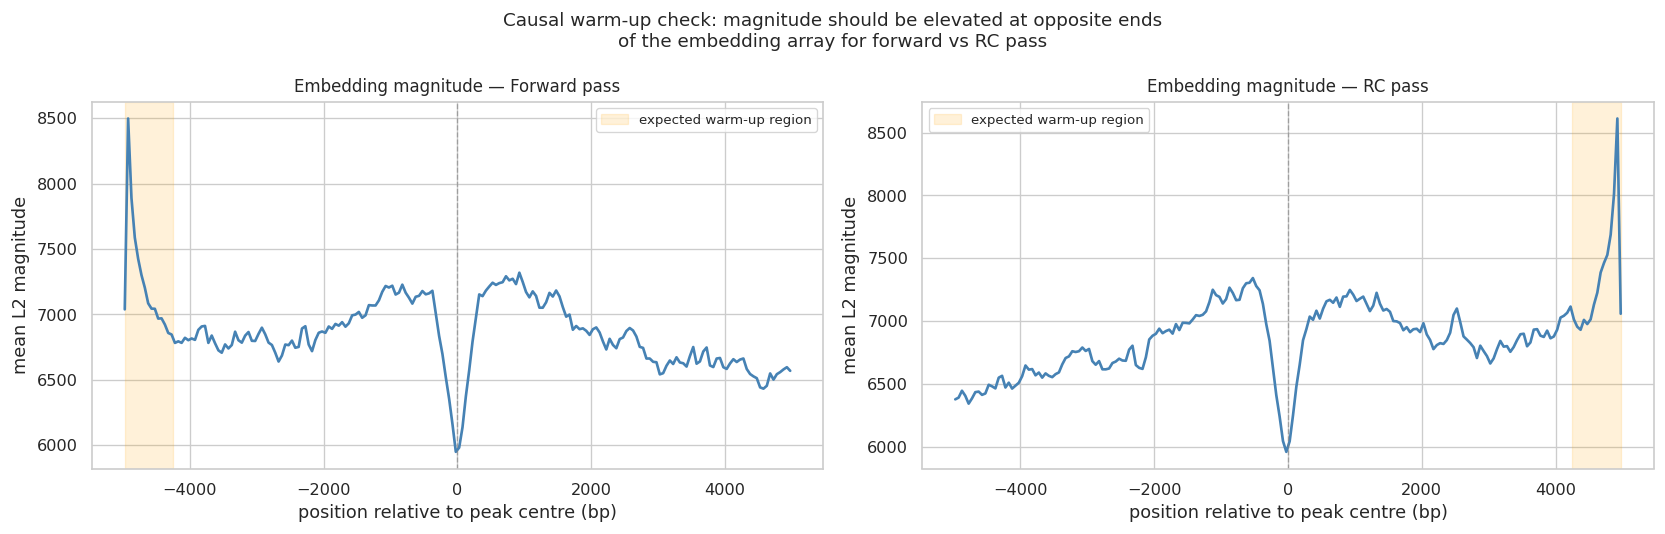

Warm-up vs body magnitude ratio
  Forward:  warm-up bins 0–14:   7245.0615  |  body: 6839.5498  |  ratio: 1.059
  RC:       warm-up bins 185–199: 7332.9551  |  body: 6835.3667  |  ratio: 1.073


In [3]:
# RC-3 — Magnitude profiles: primary causal check
#
# Hypothesis: the autoregressive warm-up artifact manifests as elevated L2
# magnitude in the first ~15 bins of the forward pass. Under a causal model
# the RC pass processes the reverse-complement sequence in the same direction;
# the warm-up should therefore appear at the LAST ~15 bins of the RC embedding
# array, corresponding to the 5' end of the original forward sequence.
#
# The RC embedding array is in the same coordinate frame as the forward array
# (bin 0 = left end of the 10 kb window). The RC sequence fed to the model
# started from what was the right end of the forward window, so model position
# 0 corresponds to genomic bin 199 and model position 199 corresponds to
# genomic bin 0. The warm-up, which elevates the first ~15 model positions,
# should therefore appear at array bins 185..199.

fwd_magnitude = np.linalg.norm(fwd_pos_profile, axis=1)      # (N_BINS,)
rc_magnitude  = np.linalg.norm(rc_pos_profile,  axis=1)      # (N_BINS,)

# Expected RC warm-up region in genomic (array) coordinates
RC_WARMUP_START = N_BINS - WARMUP_BINS   # bin 185

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=False)

for ax, (profile, label, warmup_bin, warmup_side) in zip(axes, [
    (fwd_magnitude, "Forward pass", WARMUP_BINS,       "left"),
    (rc_magnitude,  "RC pass",      RC_WARMUP_START,   "right"),
]):
    ax.plot(bin_coords, profile, color="steelblue", linewidth=1.6)
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    # shade expected warm-up region
    if warmup_side == "left":
        span = (bin_coords[0], bin_coords[warmup_bin - 1] + BIN_SIZE // 2)
    else:
        span = (bin_coords[warmup_bin] - BIN_SIZE // 2, bin_coords[-1])
    ax.axvspan(*span, color="orange", alpha=0.15, label="expected warm-up region")
    ax.set_xlabel("position relative to peak centre (bp)")
    ax.set_ylabel("mean L2 magnitude")
    ax.set_title(f"Embedding magnitude — {label}", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle(
    "Causal warm-up check: magnitude should be elevated at opposite ends\n"
    "of the embedding array for forward vs RC pass",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "revcomp_magnitude.svg", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "revcomp_magnitude.png", bbox_inches="tight")
plt.show()

# Quantify: mean magnitude in expected warm-up bins vs body
fwd_wu  = fwd_magnitude[:WARMUP_BINS].mean()
fwd_bod = fwd_magnitude[WARMUP_BINS:].mean()
rc_wu   = rc_magnitude[RC_WARMUP_START:].mean()
rc_bod  = rc_magnitude[:RC_WARMUP_START].mean()
print("Warm-up vs body magnitude ratio")
print(f"  Forward:  warm-up bins 0–{WARMUP_BINS-1}:   {fwd_wu:.4f}  |  body: {fwd_bod:.4f}  |  ratio: {fwd_wu/fwd_bod:.3f}")
print(f"  RC:       warm-up bins {RC_WARMUP_START}–199: {rc_wu:.4f}  |  body: {rc_bod:.4f}  |  ratio: {rc_wu/rc_bod:.3f}")

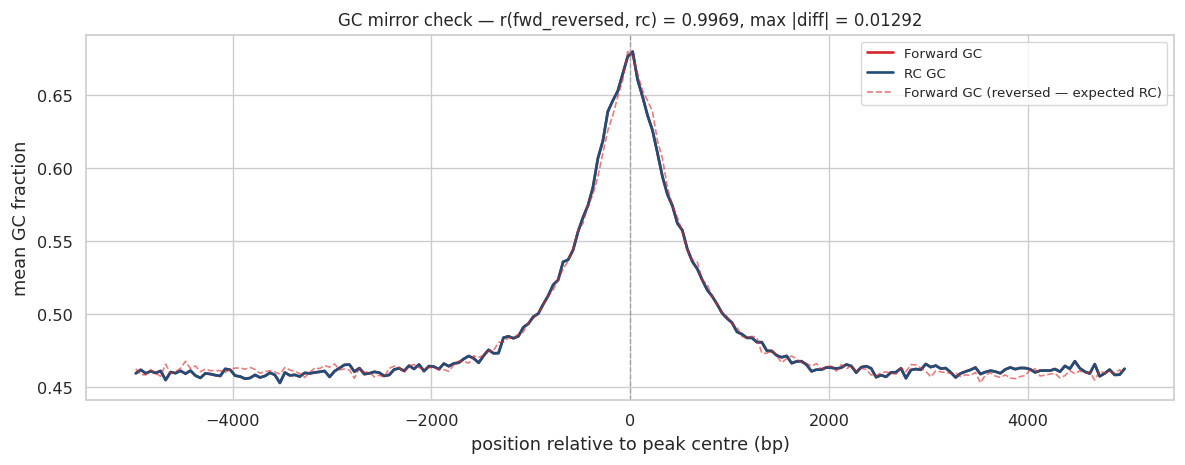

GC mirror r = 0.996857  (expected ≈ 1.0)
Max absolute deviation: 0.012922
Cache consistency check — r(computed fwd GC, cached fwd GC) = 1.000000


In [4]:
# RC-4 — GC mirror check
#
# The GC content of the reverse-complement sequence is identical to that of
# the forward sequence, but in reverse bin order (bin i of the RC sequence
# covers the same bases as bin N_BINS-1-i of the forward sequence).
# The mean GC profile of the RC sequences should therefore closely mirror
# the forward profile: rc_gc[i] ≈ fwd_gc[N_BINS-1-i].
# Large deviation would indicate a data integrity problem.

def compute_gc_profile(sequences, n_bins=N_BINS, bin_size=BIN_SIZE):
    n = len(sequences)
    gc = np.empty((n, n_bins), dtype=np.float32)
    for i, seq in enumerate(sequences):
        arr = np.frombuffer(seq.encode("ascii"), dtype=np.uint8)
        arr = arr.reshape(n_bins, bin_size)
        is_g = arr == ord("G"); is_c = arr == ord("C")
        is_a = arr == ord("A"); is_t = arr == ord("T")
        gc_count   = (is_g | is_c).sum(axis=1).astype(np.float32)
        acgt_count = (is_a | is_c | is_g | is_t).sum(axis=1).astype(np.float32)
        with np.errstate(divide="ignore", invalid="ignore"):
            gc[i] = np.where(acgt_count > 0, gc_count / acgt_count, np.nan)
    return gc


gc_fwd = compute_gc_profile(kept_seqs_fwd)   # (n_kept, N_BINS) — should match fwd_gc_mean_profile
gc_rc  = compute_gc_profile(kept_seqs_rc)

gc_fwd_mean = np.nanmean(gc_fwd, axis=0)    # (N_BINS,)
gc_rc_mean  = np.nanmean(gc_rc, axis=0)[::-1]   # flip to genomic coordinates

# The RC mean profile should closely match the forward profile reversed
gc_fwd_rev = gc_fwd_mean[::-1]
r_mirror, _ = pearsonr(gc_fwd_rev, gc_rc_mean)
max_abs_diff = np.abs(gc_fwd_rev - gc_rc_mean).max()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(bin_coords, gc_fwd_mean, color="#d62728", linewidth=1.6, label="Forward GC")
ax.plot(bin_coords, gc_rc_mean,  color="#1f4e79", linewidth=1.6, label="RC GC")
ax.plot(bin_coords, gc_fwd_rev,  color="#d62728", linewidth=1.0, linestyle="--",
        alpha=0.6, label="Forward GC (reversed — expected RC)")
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlabel("position relative to peak centre (bp)")
ax.set_ylabel("mean GC fraction")
ax.set_title(
    f"GC mirror check — r(fwd_reversed, rc) = {r_mirror:.4f}, "
    f"max |diff| = {max_abs_diff:.5f}",
    fontsize=10,
)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "revcomp_gc_mirror.svg", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "revcomp_gc_mirror.png", bbox_inches="tight")
plt.show()

print(f"GC mirror r = {r_mirror:.6f}  (expected ≈ 1.0)")
print(f"Max absolute deviation: {max_abs_diff:.6f}")
# Cross-check: our freshly-computed gc_fwd_mean should match the cached profile
r_cache, _ = pearsonr(gc_fwd_mean, fwd_gc_mean_profile)
print(f"Cache consistency check — r(computed fwd GC, cached fwd GC) = {r_cache:.6f}")

PC1 vs GC correlation (single-file PCA, trimmed bins):
  Forward pass:  r = +0.9977
  RC pass:       r = -0.9897

Note: sign may differ — PC orientation is arbitrary. Magnitude matters.


Text(0.5, 0.98, 'Block 2b PC1 vs GC -- forward and RC passes compared')

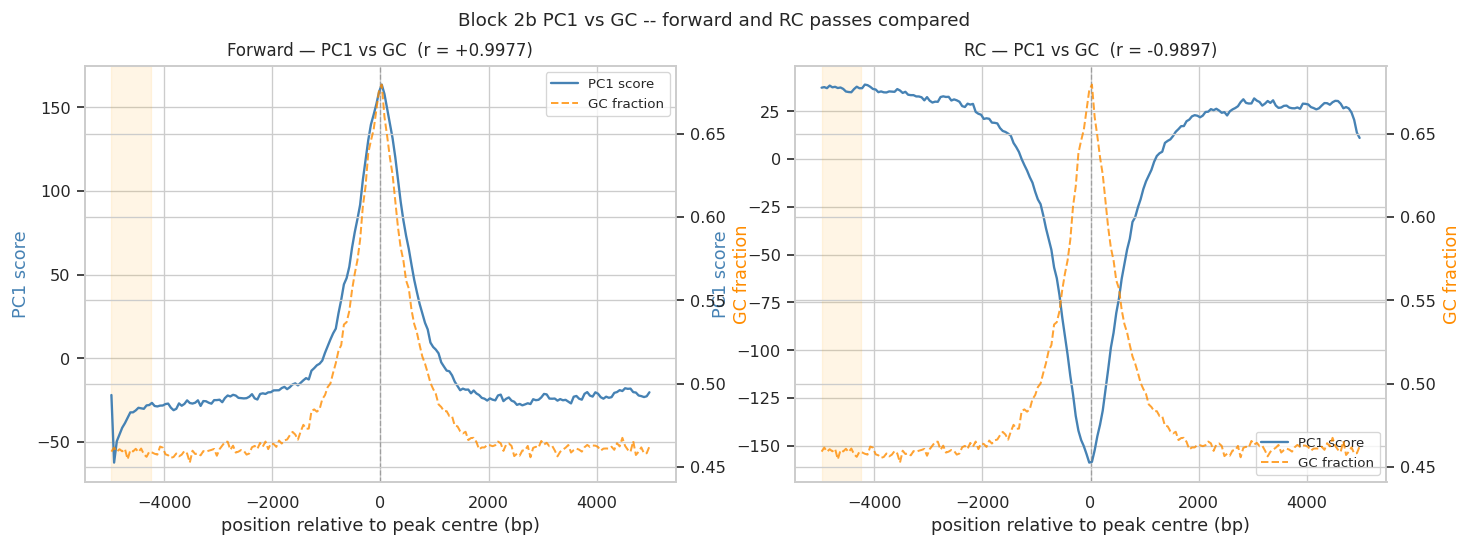

In [5]:
# RC-5 — PC1 vs GC: does the GC association survive strand flip?
#
# In the forward pass (Block 2b per-peak), PC1 of the trimmed positional PCA
# correlates strongly with per-bin GC content across all files. Here we fit
# the same PCA on the RC per-peak-normalised profile (one file only) and ask
# whether PC1 still tracks GC. Because the RC sequences are the reverse
# complements of the forward sequences, the GC profile is mirrored; if the
# embedding captures GC content causally, the correlation should remain strong
# but the sign may differ depending on how the PC aligns.
#
# We reuse the scaler and PCA fitted on the six-file forward stack (v2pp_scaler,
# v2pp_pca) if this notebook is run after 03_exploration — but to keep this
# section fully standalone we fit a fresh single-file PCA on the RC profile.

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

RC_WARMUP = WARMUP_BINS   # same trim applied to RC (bins 0..14 of RC array
                           # are the BODY of the sequence, not the warm-up,
                           # but we apply the same trim for consistency)

# Fit PCA on trimmed RC per-peak-normalised profile
# Shape going in: (1, n_trimmed_bins, EMBED_DIM) → squeezed to (n_trimmed_bins, EMBED_DIM)
rc_trimmed = rc_pos_profile_pp[trim_mask]                       # (185, EMBED_DIM)
scaler_rc  = StandardScaler(with_mean=True, with_std=True)
rc_trimmed_std = scaler_rc.fit_transform(rc_trimmed)
pca_rc = PCA(n_components=10, random_state=RANDOM_SEED).fit(rc_trimmed_std)

rc_pca_scores = pca_rc.transform(
    scaler_rc.transform(rc_pos_profile_pp)                      # project ALL bins
)                                                               # (N_BINS, 10)

# Trimmed GC profiles
gc_fwd_trim = gc_fwd_mean[trim_mask]
gc_rc_trim  = gc_rc_mean[trim_mask]

r_rc_pc1_gc, _ = pearsonr(gc_rc_trim,  rc_pca_scores[trim_mask, 0])

# Forward reference (re-read pos_pca_v2pp scores from exploration if available,
# otherwise compute inline from fwd_pos_profile_pp which is already loaded)
fwd_pp_trimmed = fwd_pos_profile[trim_mask].astype(np.float32)   # (185, EMBED_DIM)
# use same approach: fit single-file PCA for a fair comparison
scaler_fwd = StandardScaler()
fwd_pp_std = scaler_fwd.fit_transform(fwd_pp_trimmed)
pca_fwd    = PCA(n_components=10, random_state=RANDOM_SEED).fit(fwd_pp_std)
fwd_pca_scores = pca_fwd.transform(scaler_fwd.transform(fwd_pos_profile))
r_fwd_pc1_gc, _ = pearsonr(gc_fwd_mean[trim_mask], fwd_pca_scores[trim_mask, 0])

print("PC1 vs GC correlation (single-file PCA, trimmed bins):")
print(f"  Forward pass:  r = {r_fwd_pc1_gc:+.4f}")
print(f"  RC pass:       r = {r_rc_pc1_gc:+.4f}")
print()
print("Note: sign may differ — PC orientation is arbitrary. Magnitude matters.")

# Plot: PC1 profiles overlaid with GC
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, (scores, gc_mean, label, r) in zip(axes, [
    (fwd_pca_scores[:, 0], gc_fwd_mean, "Forward", r_fwd_pc1_gc),
    (rc_pca_scores[:, 0],  gc_rc_mean,  "RC",      r_rc_pc1_gc),
]):
    ax2 = ax.twinx()
    ax.plot(bin_coords, scores, color="steelblue", linewidth=1.4, label="PC1 score")
    ax2.plot(bin_coords, gc_mean, color="darkorange", linewidth=1.2,
             linestyle="--", alpha=0.8, label="GC fraction")
    ax.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axvspan(bin_coords[0], bin_coords[WARMUP_BINS - 1] + BIN_SIZE // 2,
               color="orange", alpha=0.1)
    ax.set_xlabel("position relative to peak centre (bp)")
    ax.set_ylabel("PC1 score", color="steelblue")
    ax2.set_ylabel("GC fraction", color="darkorange")
    ax.set_title(f"{label} — PC1 vs GC  (r = {r:+.4f})", fontsize=10)
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, fontsize=8)

fig.suptitle("Block 2b PC1 vs GC -- forward and RC passes compared", fontsize=11)

Computing dinucleotide profiles (forward)...
Computing dinucleotide profiles (RC)...

Pearson r(rc_contrast, expected_rc_contrast) — should be ≈ 1.0:
  AA–TT:  r = +0.9579
  CA–TG:  r = +0.9742
  AC–GT:  r = +0.9694


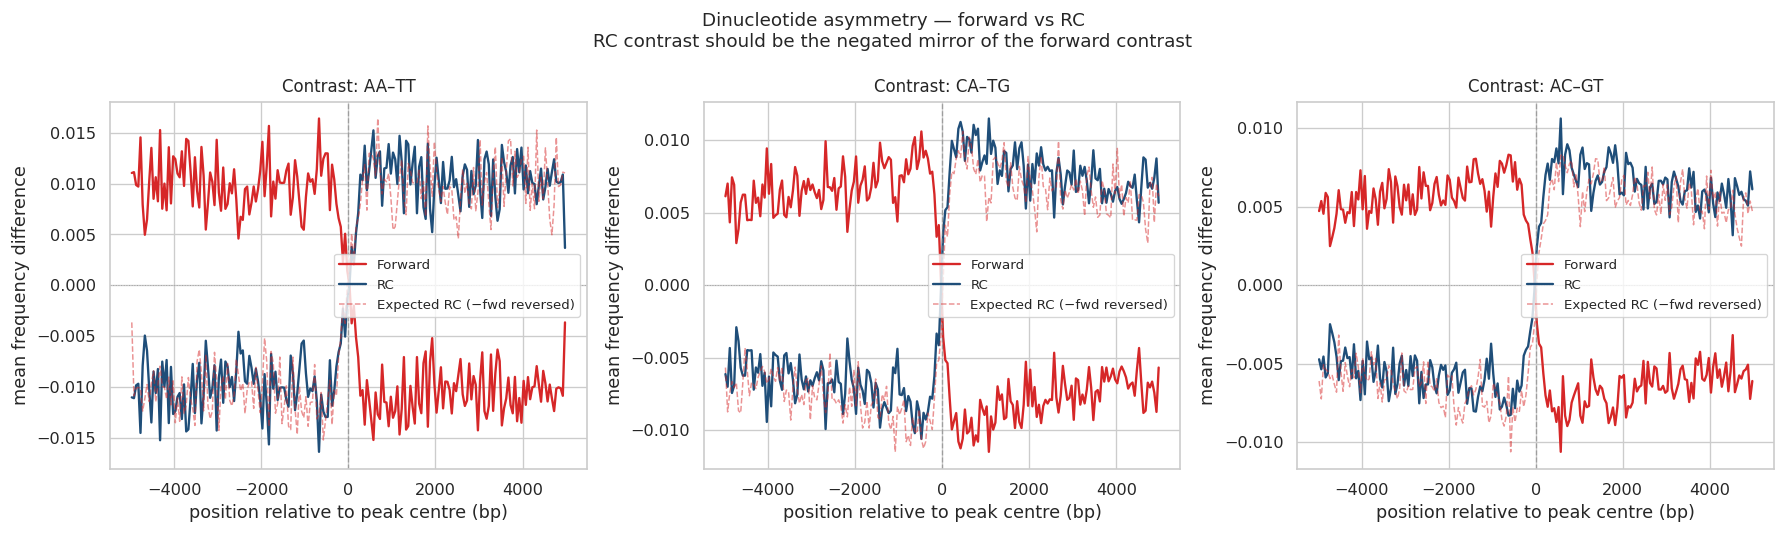

In [9]:
# RC-6 — Dinucleotide asymmetry: does the contrast invert under strand flip?
#
# Faltejsková et al. report upstream enrichment of AA/CA/AC and upstream
# depletion of their RC pairs (TT/TG/GT) around in vivo MYC binding sites.
# In the RC sequences the strand is reversed: what was upstream becomes
# downstream. The contrast profiles should therefore invert and mirror.
#
# We compute contrasts on the forward sequences (for reference) and on the RC
# sequences, then compare. Expected relationship:
#   rc_contrast[i]  ≈  -fwd_contrast[N_BINS - 1 - i]
# i.e. negated AND mirrored around bin 100.

DINUCS     = ["AA", "CA", "AC", "TT", "TG", "GT"]
DINUC_IDX  = {d: i for i, d in enumerate(DINUCS)}
contrasts  = {
    "AA–TT": (DINUC_IDX["AA"], DINUC_IDX["TT"]),
    "CA–TG": (DINUC_IDX["CA"], DINUC_IDX["TG"]),
    "AC–GT": (DINUC_IDX["AC"], DINUC_IDX["GT"]),
}

def compute_dinuc_profiles_fast(sequences, dinucs=DINUCS, n_bins=N_BINS, bin_size=BIN_SIZE):
    n = len(sequences)
    freqs = np.zeros((n, n_bins, len(dinucs)), dtype=np.float32)
    denom = bin_size - 1
    dinuc_codes = [(ord(d[0]), ord(d[1])) for d in dinucs]
    for i, seq in enumerate(sequences):
        arr   = np.frombuffer(seq.encode("ascii"), dtype=np.uint8).reshape(n_bins, bin_size)
        left  = arr[:, :-1]
        right = arr[:, 1:]
        for j, (c0, c1) in enumerate(dinuc_codes):
            freqs[i, :, j] = ((left == c0) & (right == c1)).sum(axis=1) / denom
    return freqs

print("Computing dinucleotide profiles (forward)...")
dinuc_fwd = compute_dinuc_profiles_fast(kept_seqs_fwd)   # (n_kept, N_BINS, 6)
dinuc_fwd_mean = dinuc_fwd.mean(axis=0)                  # (N_BINS, 6)
del dinuc_fwd

print("Computing dinucleotide profiles (RC)...")
dinuc_rc  = compute_dinuc_profiles_fast(kept_seqs_rc)    # (n_kept, N_BINS, 6)
dinuc_rc_mean  = dinuc_rc.mean(axis=0)[::-1, :]  # flip to genomic coordinates
del dinuc_rc

# Compute contrast profiles
contrast_fwd = {
    name: dinuc_fwd_mean[:, i] - dinuc_fwd_mean[:, j]
    for name, (i, j) in contrasts.items()
}
contrast_rc = {
    name: dinuc_rc_mean[:, i] - dinuc_rc_mean[:, j]
    for name, (i, j) in contrasts.items()
}

contrast_fwd_expected_rc = {
    name: contrast_fwd[name][::-1]
    for name in contrasts
}

print("\nPearson r(rc_contrast, expected_rc_contrast) — should be ≈ 1.0:")
for name in contrasts:
    r_check, _ = pearsonr(contrast_rc[name], contrast_fwd_expected_rc[name])
    print(f"  {name}:  r = {r_check:+.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, contrasts):
    ax.plot(bin_coords, contrast_fwd[name],             color="#d62728",
            linewidth=1.4, label="Forward")
    ax.plot(bin_coords, contrast_rc[name],              color="#1f4e79",
            linewidth=1.4, label="RC")
    ax.plot(bin_coords, contrast_fwd_expected_rc[name], color="#d62728",
            linewidth=0.9, linestyle="--", alpha=0.5, label="Expected RC (−fwd reversed)")
    ax.axvline(0,  color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axhline(0,  color="grey", linestyle=":",  linewidth=0.6, alpha=0.5)
    ax.set_title(f"Contrast: {name}", fontsize=10)
    ax.set_xlabel("position relative to peak centre (bp)")
    ax.set_ylabel("mean frequency difference")
    ax.legend(fontsize=8)

fig.suptitle(
    "Dinucleotide asymmetry — forward vs RC\n"
    "RC contrast should be the negated mirror of the forward contrast",
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "revcomp_dinuc_asymmetry.svg", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "revcomp_dinuc_asymmetry.png", bbox_inches="tight")
plt.show()

In [10]:
# RC-7 — Summary table
#
# Collects the key quantitative results from the reverse-complement test.

from scipy.stats import pearsonr

# GC mirror check
r_gc_mirror, _ = pearsonr(gc_fwd_mean[::-1], gc_rc_mean)

# PC1 vs GC (already computed in RC-5)
# Dinucleotide inversion (already computed in RC-6)
dinuc_inversion_r = {
    name: pearsonr(contrast_rc[name], contrast_fwd_expected_rc[name])[0]
    for name in contrasts
}

# Warm-up migration: is the warm-up-region mean magnitude substantially
# higher than the body in both passes?
fwd_wu_ratio = (fwd_magnitude[:WARMUP_BINS].mean()
                / fwd_magnitude[WARMUP_BINS:].mean())
rc_wu_ratio  = (rc_magnitude[RC_WARMUP_START:].mean()
                / rc_magnitude[:RC_WARMUP_START].mean())

print("=" * 60)
print("Reverse-complement diagnostic — summary")
print("=" * 60)
print(f"\n1. Warm-up magnitude ratio (warm-up region / body):")
print(f"   Forward (bins 0–{WARMUP_BINS-1} / {WARMUP_BINS}–199):   {fwd_wu_ratio:.3f}")
print(f"   RC      (bins {RC_WARMUP_START}–199 / 0–{RC_WARMUP_START-1}):   {rc_wu_ratio:.3f}")
print(f"   Interpretation: ratio >> 1 on both sides confirms causal warm-up.")

print(f"\n2. GC mirror check:")
print(f"   r(fwd GC reversed, rc GC) = {r_gc_mirror:.6f}  (expected ≈ 1.0)")

print(f"\n3. PC1 vs GC (single-file trimmed PCA):")
print(f"   Forward: r = {r_fwd_pc1_gc:+.4f}")
print(f"   RC:      r = {r_rc_pc1_gc:+.4f}")
print(f"   Interpretation: |r| should be comparable; sign may differ.")

print(f"\n4. Dinucleotide asymmetry inversion:")
print(f"   r(rc_contrast, -fwd_contrast_reversed):")
for name, r in dinuc_inversion_r.items():
    print(f"     {name}: {r:+.4f}  (expected ≈ +1.0)")
print(f"   Interpretation: r ≈ 1.0 confirms the asymmetry signal is strand-sensitive.")
print("=" * 60)

Reverse-complement diagnostic — summary

1. Warm-up magnitude ratio (warm-up region / body):
   Forward (bins 0–14 / 15–199):   1.059
   RC      (bins 185–199 / 0–184):   1.073
   Interpretation: ratio >> 1 on both sides confirms causal warm-up.

2. GC mirror check:
   r(fwd GC reversed, rc GC) = 0.996857  (expected ≈ 1.0)

3. PC1 vs GC (single-file trimmed PCA):
   Forward: r = +0.9977
   RC:      r = -0.9897
   Interpretation: |r| should be comparable; sign may differ.

4. Dinucleotide asymmetry inversion:
   r(rc_contrast, -fwd_contrast_reversed):
     AA–TT: +0.9579  (expected ≈ +1.0)
     CA–TG: +0.9742  (expected ≈ +1.0)
     AC–GT: +0.9694  (expected ≈ +1.0)
   Interpretation: r ≈ 1.0 confirms the asymmetry signal is strand-sensitive.


In [8]:
# RC-3b — Narrow warm-up check: bins 0-2 vs body, and RC bins 197-199 vs body

for n_wu_bins in [1, 2, 3, 5]:
    fwd_wu  = fwd_magnitude[:n_wu_bins].mean()
    fwd_bod = fwd_magnitude[n_wu_bins:N_BINS - n_wu_bins].mean()
    rc_wu   = rc_magnitude[N_BINS - n_wu_bins:].mean()
    rc_bod  = rc_magnitude[:N_BINS - n_wu_bins].mean()
    print(
        f"n_wu_bins={n_wu_bins:2d} | "
        f"fwd: {fwd_wu:.1f}/{fwd_bod:.1f} = {fwd_wu/fwd_bod:.4f} | "
        f"rc:  {rc_wu:.1f}/{rc_bod:.1f} = {rc_wu/rc_bod:.4f}"
    )

n_wu_bins= 1 | fwd: 7038.3/6870.6 = 1.0244 | rc:  7057.8/6871.8 = 1.0271
n_wu_bins= 2 | fwd: 7767.8/6863.7 = 1.1317 | rc:  7834.9/6863.0 = 1.1416
n_wu_bins= 3 | fwd: 7808.2/6859.9 = 1.1382 | rc:  7893.7/6857.1 = 1.1512
n_wu_bins= 5 | fwd: 7687.3/6856.4 = 1.1212 | rc:  7779.0/6849.4 = 1.1357
